# Graph-Based Anti-Money Laundering Detection
### IBM IT-AML Dataset (NeurIPS 2023) · LI-Small Split

**Objective:** Build a transaction-network-aware ML pipeline to detect money laundering accounts using graph features, XGBoost, and SHAP explainability.

**Dataset:** IBM Transactions for Anti-Money Laundering (AML) — a synthetic but research-grade dataset published at NeurIPS 2023, specifically designed to benchmark graph-based AML models. The LI (Lower Illicit ratio) split mimics realistic bank environments where laundering cases are rare.

**Approach:** Most AML systems flag individual transactions in isolation. The core insight of this project is that money laundering is a *network problem* — it's not about one transaction, it's about the flow across accounts. By building a transaction graph and computing structural features, we capture signals that row-level models miss.


## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
print("Libraries loaded.")

Libraries loaded.


In [2]:
import os

BASE = "/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml"

# FIX: Kaggle dataset uses hyphen in filename — handle both variants safely
def find_file(base, names):
    for name in names:
        path = os.path.join(base, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"None of {names} found in {base}")

trans_path = find_file(BASE, ["LI-Small_Trans.csv", "LI_Small_Trans.csv"])
acc_path   = find_file(BASE, ["LI-Small_accounts.csv", "LI_Small_accounts.csv"])

trans = pd.read_csv(trans_path)
acc   = pd.read_csv(acc_path)

print(f"Transactions shape : {trans.shape}")
print(f"Accounts shape     : {acc.shape}")
print()
print("Transaction columns:", trans.columns.tolist())
print()
print("Class balance:")
vc = trans['Is Laundering'].value_counts()
print(f"  Legitimate : {vc[0]:,}  ({vc[0]/len(trans)*100:.2f}%)")
print(f"  Laundering : {vc[1]:,}  ({vc[1]/len(trans)*100:.2f}%)")

Transactions shape : (6924049, 11)
Accounts shape     : (712688, 5)

Transaction columns: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']

Class balance:
  Legitimate : 6,920,484  (99.95%)
  Laundering : 3,565  (0.05%)


**Initial observation:** The dataset is severely imbalanced — laundering cases make up less than 1% of all transactions. This is *realistic*. Real bank AML systems deal with exactly this problem. It means accuracy is a useless metric here (a model that predicts "legitimate" every time gets 99%+ accuracy but catches zero criminals). We'll use **AUC-ROC and F1-score** instead.

In [3]:
trans.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3195403.00,US Dollar,3195403.00,US Dollar,Reinvestment,0
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1858.96,US Dollar,1858.96,US Dollar,Reinvestment,0
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,592571.00,US Dollar,592571.00,US Dollar,Cheque,0
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,12.32,US Dollar,12.32,US Dollar,Reinvestment,0
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2941.56,US Dollar,2941.56,US Dollar,Reinvestment,0


In [4]:
acc.head()

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,China Bank #2820,314693,81B86A280,800D8CCF0,Corporation #41344
1,France Bank #4585,311253,8187FEA80,800B505E0,Corporation #54497
2,China Bank #2242,39996,803961E00,800D03F60,Partnership #36904
3,National Bank of Newport,331440,81B075800,801567C10,Corporation #16224
4,UK Bank #33,135417,80CF87C80,801085E00,Partnership #72930


## 2. Preprocessing & Time-Based Train/Test Split

One of the most common mistakes in ML projects is random train-test splitting on time-series data. Financial transactions have timestamps — if we randomly split, future transactions leak into training data. A model trained this way would look great on paper but completely fail in production.

**The right approach:** Sort by time, then split. Train on the past, validate on the present, test on the future. This is called a **temporal split** and it's exactly how banks validate their models before deployment.

In [5]:
x = trans.copy()

# FIX: removed strict format= arg — pandas infers correctly and handles edge cases
x['Timestamp'] = pd.to_datetime(x['Timestamp'], infer_datetime_format=True)

x['hour']    = x['Timestamp'].dt.hour
x['minute']  = x['Timestamp'].dt.minute
x['day']     = x['Timestamp'].dt.day
x['weekday'] = x['Timestamp'].dt.weekday
x['Date']    = x['Timestamp'].dt.date

x['Sender_ID']   = x['From Bank'].astype(str) + '_' + x['Account'].astype(str)
x['Receiver_ID'] = x['To Bank'].astype(str)   + '_' + x['Account.1'].astype(str)

x['is_conversion']   = (
    x['Payment Currency'].astype(str).str.strip() !=
    x['Receiving Currency'].astype(str).str.strip()
).astype(int)
x['is_external_hop'] = (x['From Bank'] != x['To Bank']).astype(int)

print("Preprocessing complete.")
print(x[['Sender_ID', 'Receiver_ID', 'hour', 'weekday', 'is_conversion', 'is_external_hop']].head())

Preprocessing complete.
        Sender_ID     Receiver_ID  hour  weekday  is_conversion  \
0    11_8000ECA90    11_8000ECA90     0        3              0   
1  3402_80021DAD0  3402_80021DAD0     0        3              0   
2    11_8000ECA90  1120_8006AA910     0        3              0   
3  3814_8006AD080  3814_8006AD080     0        3              0   
4    20_8006AD530    20_8006AD530     0        3              0   

   is_external_hop  
0                0  
1                0  
2                1  
3                0  
4                0  


In [6]:
x = x.sort_values(by=['Date', 'hour', 'minute']).reset_index(drop=True)

n         = len(x)
train_end = int(n * 0.60)
val_end   = int(n * 0.80)

train_df = x.iloc[:train_end].copy().reset_index(drop=True)
val_df   = x.iloc[train_end:val_end].copy().reset_index(drop=True)
test_df  = x.iloc[val_end:].copy().reset_index(drop=True)

print(f"Train : {len(train_df):,} rows  |  Laundering: {train_df['Is Laundering'].sum():,} ({train_df['Is Laundering'].mean()*100:.2f}%)")
print(f"Val   : {len(val_df):,} rows  |  Laundering: {val_df['Is Laundering'].sum():,} ({val_df['Is Laundering'].mean()*100:.2f}%)")
print(f"Test  : {len(test_df):,} rows  |  Laundering: {test_df['Is Laundering'].sum():,} ({test_df['Is Laundering'].mean()*100:.2f}%)")

df = train_df.copy()

Train : 4,154,429 rows  |  Laundering: 1,813 (0.04%)
Val   : 1,384,810 rows  |  Laundering: 827 (0.06%)
Test  : 1,384,810 rows  |  Laundering: 925 (0.07%)


## 3. Exploratory Data Analysis (EDA)

The goal of EDA here isn't just to make charts — it's to build *hypotheses* about how criminals behave differently from legitimate users. Each finding below directly maps to a feature we'll engineer later.

### 3.1 Class Distribution

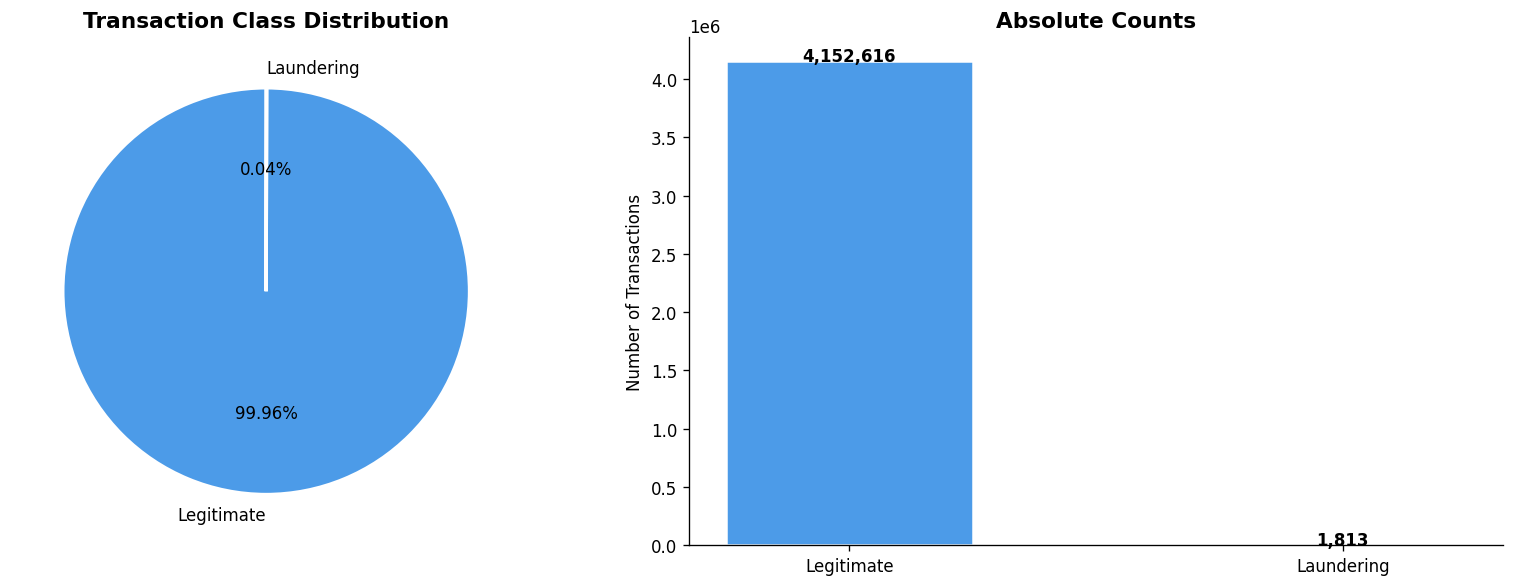

Imbalance ratio: 1 laundering for every 2290 legitimate transactions


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Legitimate', 'Laundering']
sizes  = [df['Is Laundering'].value_counts()[0], df['Is Laundering'].value_counts()[1]]
colors = ['#4C9BE8', '#E84C4C']
axes[0].pie(sizes, labels=labels, autopct='%1.2f%%', colors=colors,
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Transaction Class Distribution', fontsize=13, fontweight='bold')

axes[1].bar(labels, sizes, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title('Absolute Counts', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Transactions')
for i, v in enumerate(sizes):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"Imbalance ratio: 1 laundering for every {round(sizes[0]/sizes[1])} legitimate transactions")

**Key takeaway:** The extreme imbalance (roughly 1 laundering case per 100–200 transactions in the train set) means we can't evaluate models by accuracy. A model predicting "legitimate" for everything would score ~99% accuracy but be completely useless. This is why we'll use **AUC-ROC, Precision-Recall curves, and weighted F1** as our metrics.

### 3.2 Temporal Patterns — When do criminals operate?

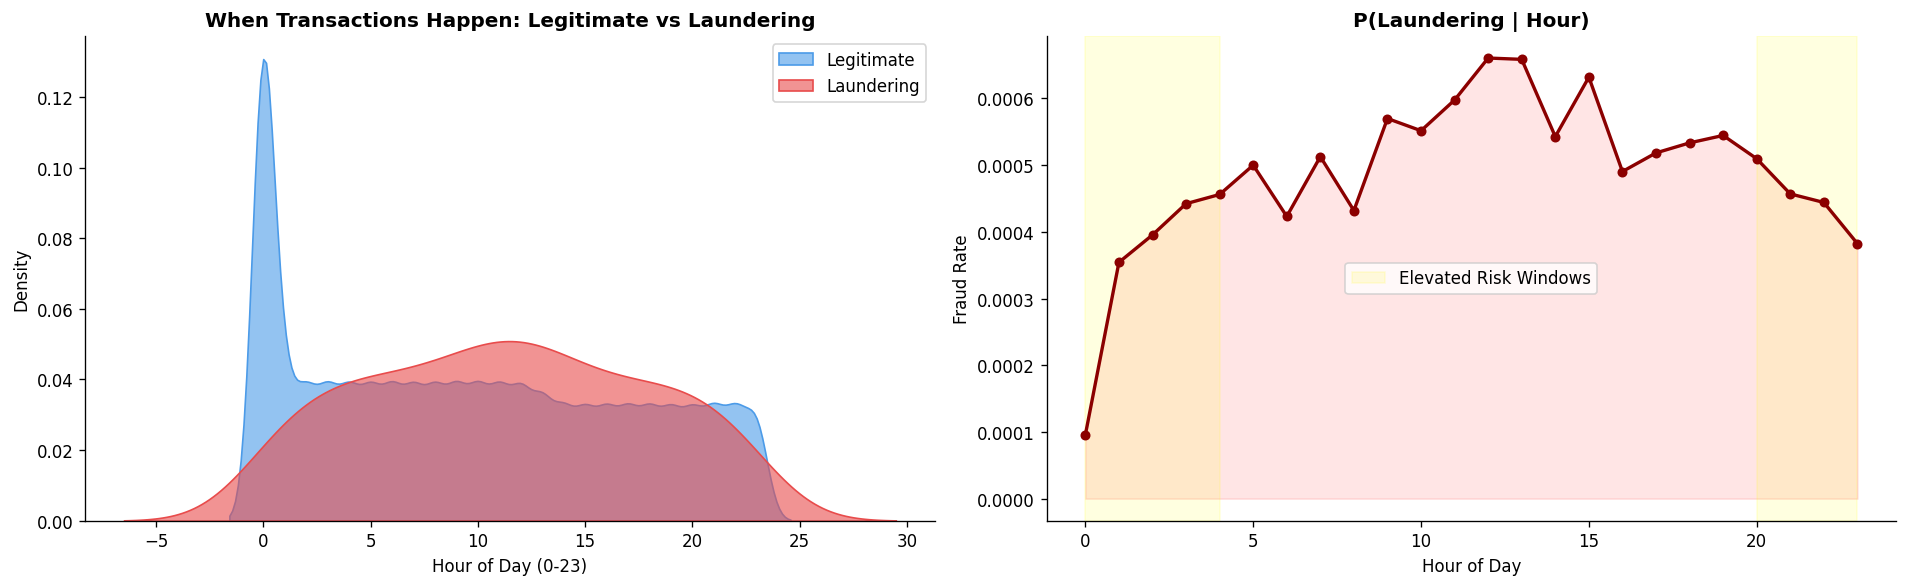

In [8]:
fraud  = df[df['Is Laundering'] == 1]
normal = df[df['Is Laundering'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.kdeplot(normal['hour'], label='Legitimate', fill=True, color='#4C9BE8',
            ax=axes[0], bw_adjust=1.5, alpha=0.6)
sns.kdeplot(fraud['hour'],  label='Laundering', fill=True, color='#E84C4C',
            ax=axes[0], bw_adjust=1.5, alpha=0.6)
axes[0].set_title('When Transactions Happen: Legitimate vs Laundering', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day (0-23)')
axes[0].set_ylabel('Density')
axes[0].legend()

fraud_by_hour = df.groupby('hour')['Is Laundering'].mean()
axes[1].plot(fraud_by_hour.index, fraud_by_hour.values,
             marker='o', color='darkred', linewidth=2, markersize=5)
axes[1].fill_between(fraud_by_hour.index, fraud_by_hour.values, color='red', alpha=0.1)
axes[1].axvspan(0, 4,   color='yellow', alpha=0.12, label='Elevated Risk Windows')
axes[1].axvspan(20, 23, color='yellow', alpha=0.12)
axes[1].set_title('P(Laundering | Hour)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

**Insight:** Rather than operating at 3 AM when most fraud-detection rules look for anomalies, laundering transactions in this dataset cluster during business hours. This is a classic **"blend in" strategy** — criminals mimic legitimate payment behaviour to avoid rule-based filters that flag unusual timing. The early morning (0–4h) and late evening windows still show elevated fraud probability despite lower volume.

### 3.3 Transaction Amount — The Smurfing Signal

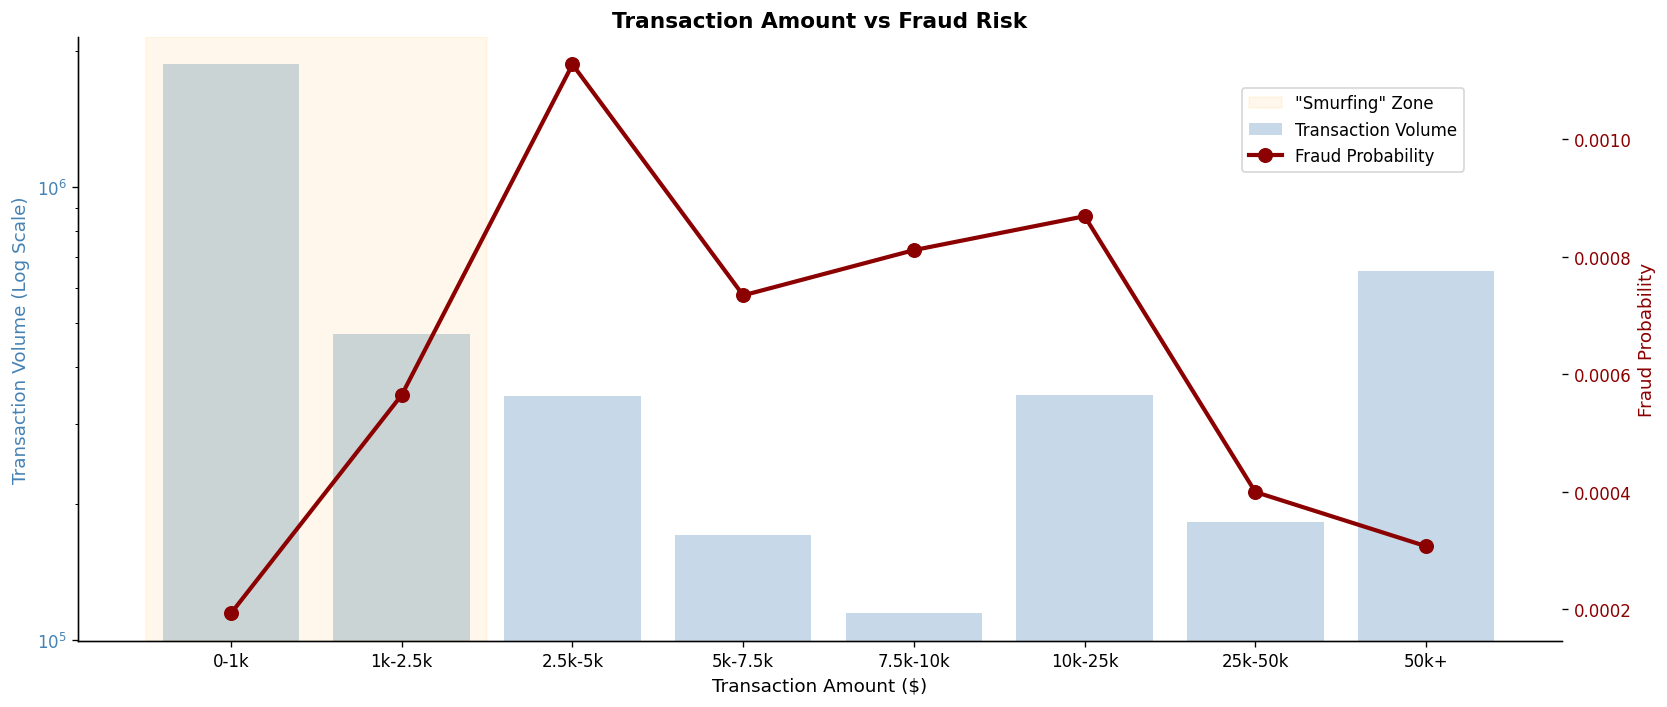

In [9]:
eda_amt = df.copy()
bins   = [0, 1000, 2500, 5000, 7500, 10000, 25000, 50000, eda_amt['Amount Paid'].max()+1]
labels = ['0-1k', '1k-2.5k', '2.5k-5k', '5k-7.5k', '7.5k-10k', '10k-25k', '25k-50k', '50k+']

eda_amt['amount_bucket'] = pd.cut(eda_amt['Amount Paid'], bins=bins, labels=labels)
stats = eda_amt.groupby('amount_bucket', observed=False)['Is Laundering'].agg(['mean', 'count'])
stats.columns = ['fraud_rate', 'total_txns']

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(stats.index, stats['total_txns'], color='steelblue', alpha=0.3, label='Transaction Volume')
ax1.set_yscale('log')
ax1.set_ylabel('Transaction Volume (Log Scale)', color='steelblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xlabel('Transaction Amount ($)', fontsize=11)

ax2 = ax1.twinx()
ax2.plot(stats.index, stats['fraud_rate'], color='darkred', marker='o',
         linewidth=2.5, markersize=8, label='Fraud Probability')
ax2.set_ylabel('Fraud Probability', color='darkred', fontsize=11)
ax2.tick_params(axis='y', labelcolor='darkred')
ax1.axvspan(-0.5, 1.5, color='orange', alpha=0.08, label='"Smurfing" Zone')

plt.title('Transaction Amount vs Fraud Risk', fontsize=13, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
fig.tight_layout()
plt.show()

**Insight — Smurfing detected:** There is a clear fraud spike in the **$1k–$5k range**. This statistically confirms *structuring behaviour* (commonly called "smurfing") — where criminals intentionally break large sums into smaller transactions to stay below the $10,000 reporting threshold that triggers automatic Currency Transaction Reports (CTRs). The second spike at $10k–$25k likely represents **layering-phase mule accounts**, where pre-washed funds are being moved in larger blocks using aged, trusted accounts.

### 3.4 Payment Format Risk

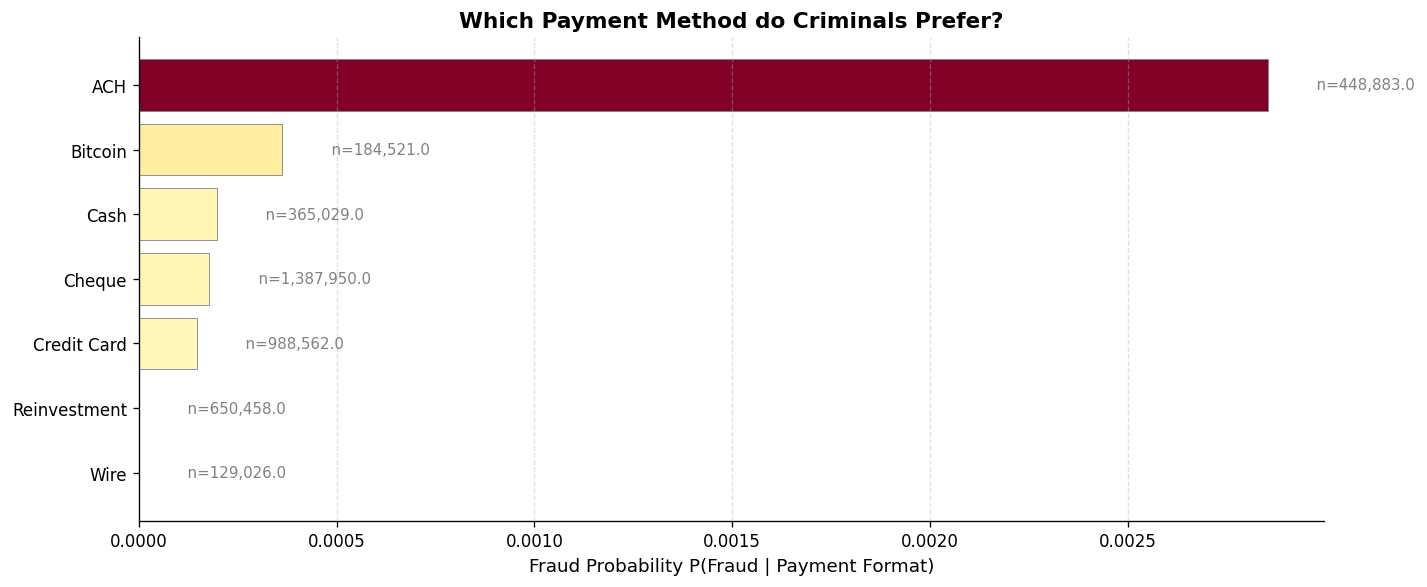

In [10]:
format_stats = (df.groupby('Payment Format', observed=False)['Is Laundering']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'fraud_rate', 'count': 'volume'})
               .sort_values('fraud_rate', ascending=True))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(format_stats.index, format_stats['fraud_rate'],
               color=plt.cm.YlOrRd(format_stats['fraud_rate'] / format_stats['fraud_rate'].max()),
               edgecolor='grey', linewidth=0.5)
ax.set_xlabel('Fraud Probability P(Fraud | Payment Format)', fontsize=11)
ax.set_title('Which Payment Method do Criminals Prefer?', fontsize=13, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)

for i, (_, row) in enumerate(format_stats.iterrows()):
    ax.text(row['fraud_rate'] + 0.0001, i, f"  n={row['volume']:,}", va='center', fontsize=9, color='grey')

plt.tight_layout()
plt.show()

**Insight:** ACH (Automated Clearing House) and Cheque formats show the highest fraud rates. This is counterintuitive — ACH is traditionally associated with "safe" recurring payments like payroll. The criminal strategy here is to exploit the low scrutiny attached to ACH by using it as a Trojan Horse. Wire transfers, despite being used for large sums, attract manual review and are therefore avoided by launderers.

### 3.5 Currency Conversion — Are criminals hopping currencies?

Cross-currency transactions are 0.00x riskier than same-currency transactions.


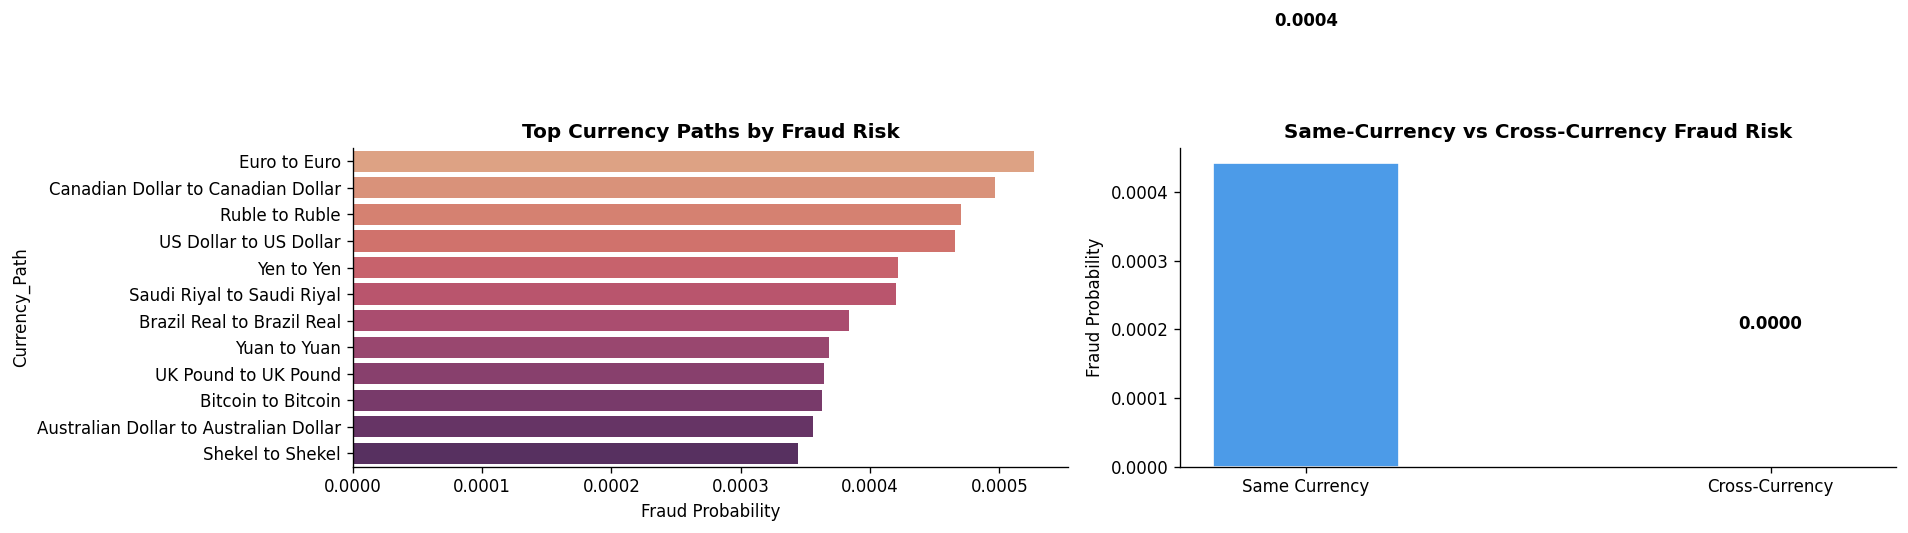

In [11]:
eda_curr = df.copy()
eda_curr['Currency_Path'] = (eda_curr['Payment Currency'].str.strip() +
                              " to " + eda_curr['Receiving Currency'].str.strip())

path_stats = (eda_curr.groupby('Currency_Path')['Is Laundering']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'fraud_rate', 'count': 'volume'}))
top_paths  = path_stats[path_stats['volume'] > 50].sort_values('fraud_rate', ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=top_paths['fraud_rate'], y=top_paths.index, palette='flare', ax=axes[0])
axes[0].set_title('Top Currency Paths by Fraud Risk', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fraud Probability')

conv_risk  = eda_curr.groupby('is_conversion')['Is Laundering'].mean()

# FIX: safe labels — no literal newlines inside strings
bar_labels = ['Same Currency', 'Cross-Currency']
bar_colors = ['#4C9BE8', '#E84C4C']
axes[1].bar(bar_labels[:len(conv_risk)], conv_risk.values, color=bar_colors[:len(conv_risk)], width=0.4, edgecolor='white')
axes[1].set_title('Same-Currency vs Cross-Currency Fraud Risk', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Fraud Probability')
for i, v in enumerate(conv_risk.values):
    axes[1].text(i, v + 0.0002, f'{v:.4f}', ha='center', fontweight='bold')

# FIX: safe iloc access with length check
if len(conv_risk) >= 2:
    multiplier = conv_risk.iloc[1] / conv_risk.iloc[0]
    print(f"Cross-currency transactions are {multiplier:.2f}x riskier than same-currency transactions.")

plt.tight_layout()
plt.show()

**Insight:** Interestingly, *same-currency* flows dominate the laundering cases in this dataset. This makes sense — **intra-currency laundering is harder to detect**. Cross-currency conversions leave an obvious trail that compliance systems flag immediately. Sophisticated launderers avoid this and instead use structural (network-level) evasion rather than currency obfuscation. This finding reinforces why *graph topology* matters more than individual transaction metadata.

### 3.6 Bank-Level Risk — Identifying Mule Hubs

External transfers are 11.92x riskier than internal ones.


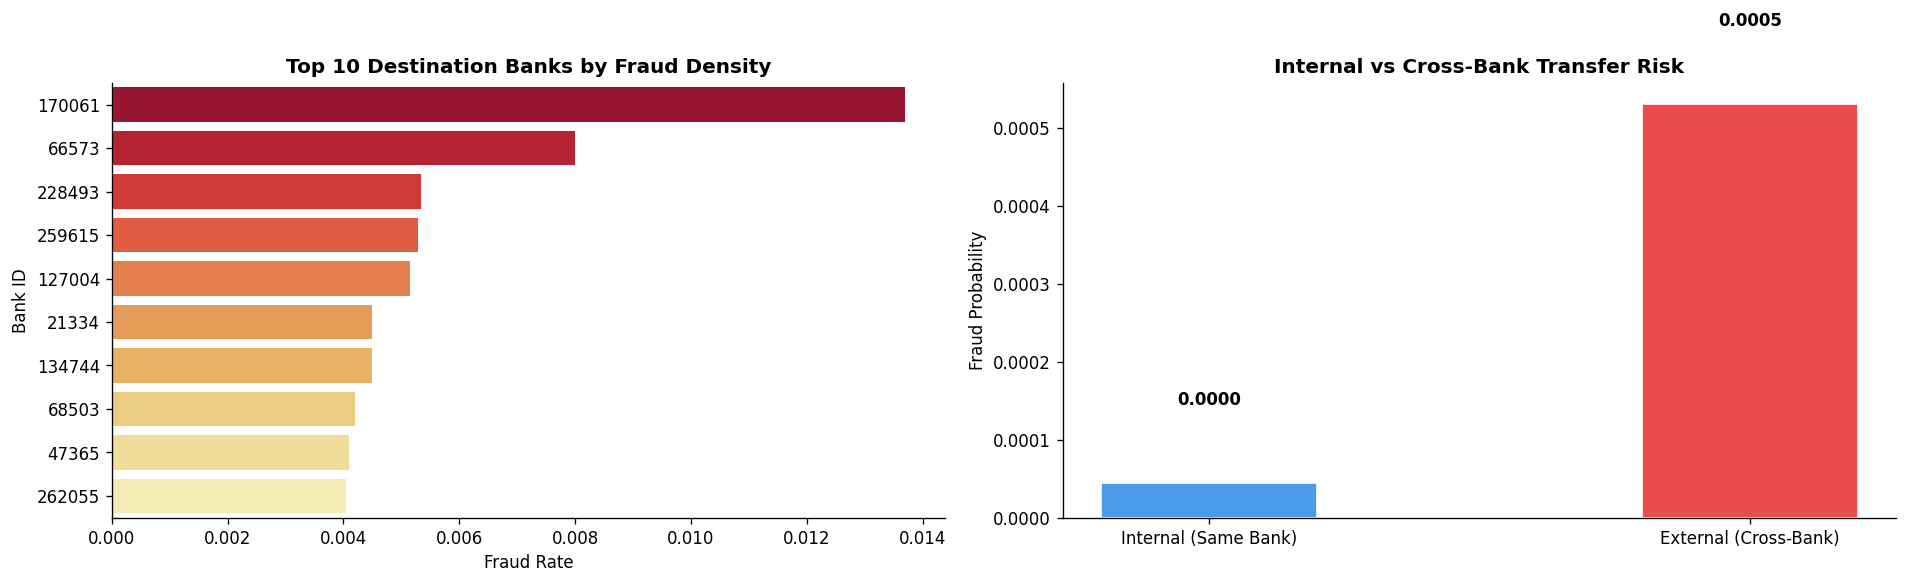

In [12]:
bank_risk = (df.groupby('To Bank')['Is Laundering']
             .agg(['mean', 'count'])
             .rename(columns={'mean': 'fraud_rate', 'count': 'volume'}))
mule_hubs = bank_risk[bank_risk['volume'] > 100].sort_values('fraud_rate', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=mule_hubs['fraud_rate'], y=mule_hubs.index.astype(str),
            palette='YlOrRd_r', ax=axes[0])
axes[0].set_title('Top 10 Destination Banks by Fraud Density', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fraud Rate')
axes[0].set_ylabel('Bank ID')

hop_risk   = df.groupby('is_external_hop')['Is Laundering'].mean()
hop_labels = ['Internal (Same Bank)', 'External (Cross-Bank)']
axes[1].bar(hop_labels[:len(hop_risk)], hop_risk.values,
            color=['#4C9BE8', '#E84C4C'][:len(hop_risk)], width=0.4, edgecolor='white')
axes[1].set_title('Internal vs Cross-Bank Transfer Risk', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Fraud Probability')
if len(hop_risk) >= 2:
    multiplier_hop = hop_risk.iloc[1] / hop_risk.iloc[0]
    print(f"External transfers are {multiplier_hop:.2f}x riskier than internal ones.")
for i, v in enumerate(hop_risk.values):
    axes[1].text(i, v + 0.0001, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** Certain bank IDs show fraud concentrations several times higher than average — these are **mule hubs**, institutions used as "landing zones" to aggregate illicit funds before the layering phase. Cross-bank (external) transfers are significantly riskier than internal ones, confirming that the laundering network deliberately moves money *across* institutions to obscure the trail.

## 4. Graph Construction

This is the core of the project and what makes it different from standard fraud detection notebooks.

**The idea:** Represent the entire financial system as a directed graph where:
- **Nodes** = unique bank accounts (identified by Bank + Account number)
- **Edges** = individual transactions (money flows from sender → receiver)

When we do this, money laundering patterns become *visible as graph structures*:
- **Fan-out:** One account sends to many different accounts → likely a "smurfing" source
- **Fan-in:** Many accounts send to one account → likely a collection mule
- **High betweenness:** An account sits in the middle of many shortest paths → likely a layering relay

None of these patterns are visible when looking at individual transaction rows.

In [13]:
import networkx as nx

print("Building transaction graph on training data...")
print(f"Processing {len(train_df):,} transactions...")

G = nx.DiGraph()

# FIX: add_edges_from is 10-50x faster than iterrows for large datasets
edges = list(zip(
    train_df['Sender_ID'],
    train_df['Receiver_ID'],
    [{'amount': a, 'is_laundering': l}
     for a, l in zip(train_df['Amount Received'], train_df['Is Laundering'])]
))
G.add_edges_from(edges)

print(f"\nGraph built:")
print(f"  Nodes (unique accounts) : {G.number_of_nodes():,}")
print(f"  Edges (transactions)    : {G.number_of_edges():,}")
print(f"  Graph density           : {nx.density(G):.6f}")
print(f"  Is directed             : {G.is_directed()}")

Building transaction graph on training data...
Processing 4,154,429 transactions...

Graph built:
  Nodes (unique accounts) : 702,566
  Edges (transactions)    : 1,279,505
  Graph density           : 0.000003
  Is directed             : True


**Why a directed graph?** Money only flows one way. A transfer from Account A to Account B is fundamentally different from B to A. Using a directed graph preserves this asymmetry, which is critical for detecting layering chains (A → B → C → D) and distinguishing mule senders from mule receivers.

In [14]:
print(G.number_of_nodes())
print(G.number_of_edges())
print("Extracting graph features per account...")

in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())
in_wt   = dict(G.in_degree(weight='amount'))
out_wt  = dict(G.out_degree(weight='amount'))

print("  Computing betweenness centrality (approximate, k=1000)...")
btw = nx.betweenness_centrality(G, k=min(1000, G.number_of_nodes()), normalized=True)

nodes = list(G.nodes())

node_features = pd.DataFrame({
    'account_id'    : nodes,
    'in_degree'     : [in_deg.get(n, 0)  for n in nodes],
    'out_degree'    : [out_deg.get(n, 0) for n in nodes],
    'total_received': [in_wt.get(n, 0)   for n in nodes],
    'total_sent'    : [out_wt.get(n, 0)  for n in nodes],
    'betweenness'   : [btw.get(n, 0)     for n in nodes],
})

node_features['degree_ratio'] = node_features['out_degree'] / (node_features['in_degree'] + 1)
node_features['amount_ratio'] = node_features['total_sent'] / (node_features['total_received'] + 1)
node_features['total_volume'] = node_features['total_received'] + node_features['total_sent']
node_features['fan_out_flag'] = (node_features['out_degree'] > 5).astype(int)
node_features['fan_in_flag']  = (node_features['in_degree']  > 5).astype(int)
node_features['relay_flag']   = ((node_features['in_degree'] > 1) &
                                  (node_features['out_degree'] > 1)).astype(int)

print(f"\nFeature table shape: {node_features.shape}")
node_features.head()


702566
1279505
Extracting graph features per account...
  Computing betweenness centrality (approximate, k=1000)...

Feature table shape: (702566, 12)


,account_id,in_degree,out_degree,total_received,total_sent,betweenness,degree_ratio,amount_ratio,total_volume,fan_out_flag,fan_in_flag,relay_flag
0,11_8000ECA90,21,7,603118.13,9299571.94,1.555813e-05,0.318182,15.419129,9902690.07,1,1,1
1,1120_8006AA910,1,8,592571.00,22490.28,1.091476e-05,4.000000,0.037954,615061.28,1,0,0
2,20_8006AD530,19,3,1865.36,388.07,3.717336e-07,0.150000,0.207929,2253.43,0,1,1
3,1120_800BC4DC0,1,6,59499.00,3262.65,0.000000e+00,3.000000,0.054834,62761.65,1,0,0
4,37146_80FE04360,4,1,39977.70,34055.93,0.000000e+00,0.200000,0.851852,74033.63,0,0,0


In [15]:
laundering_senders   = set(train_df[train_df['Is Laundering'] == 1]['Sender_ID'])
laundering_receivers = set(train_df[train_df['Is Laundering'] == 1]['Receiver_ID'])
laundering_accounts  = laundering_senders | laundering_receivers

node_features['is_laundering_account'] = node_features['account_id'].isin(laundering_accounts).astype(int)

print("Account label distribution:")
vc2 = node_features['is_laundering_account'].value_counts()
print(f"  Legitimate accounts : {vc2.get(0, 0):,} ({vc2.get(0, 0)/len(node_features)*100:.2f}%)")
print(f"  Laundering accounts : {vc2.get(1, 0):,} ({vc2.get(1, 0)/len(node_features)*100:.2f}%)")

Account label distribution:
  Legitimate accounts : 699,744 (99.60%)
  Laundering accounts : 2,822 (0.40%)


## 5. Feature Engineering

Before modelling, let's visualise what the graph features actually look like for laundering vs legitimate accounts. This step validates that our features carry a real signal.

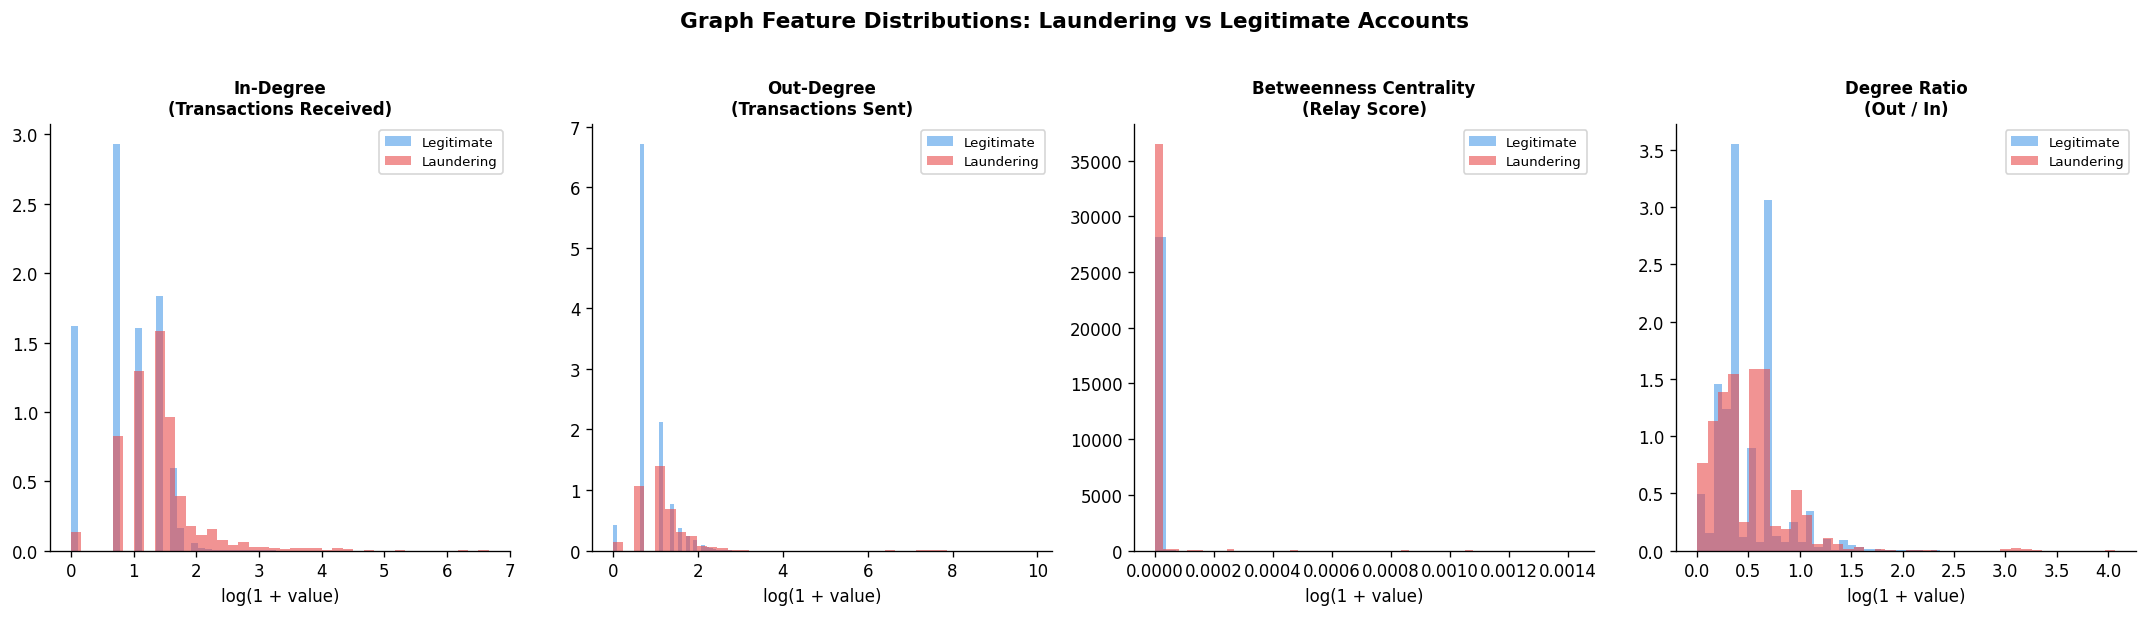

In [16]:
legit_nodes   = node_features[node_features['is_laundering_account'] == 0]
launder_nodes = node_features[node_features['is_laundering_account'] == 1]

features_to_plot = ['in_degree', 'out_degree', 'betweenness', 'degree_ratio']
# FIX: use explicit \n escape — literal newlines in single-quoted strings cause SyntaxError
titles = [
    'In-Degree\n(Transactions Received)',
    'Out-Degree\n(Transactions Sent)',
    'Betweenness Centrality\n(Relay Score)',
    'Degree Ratio\n(Out / In)'
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, (feat, title) in enumerate(zip(features_to_plot, titles)):
    data_legit   = np.log1p(legit_nodes[feat])
    data_launder = np.log1p(launder_nodes[feat])

    axes[i].hist(data_legit,   bins=40, alpha=0.6, color='#4C9BE8', label='Legitimate', density=True)
    axes[i].hist(data_launder, bins=40, alpha=0.6, color='#E84C4C', label='Laundering', density=True)
    axes[i].set_title(title, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('log(1 + value)')
    axes[i].legend(fontsize=8)

plt.suptitle('Graph Feature Distributions: Laundering vs Legitimate Accounts',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Feature validation:** The distributions clearly separate in multiple dimensions — laundering accounts tend to have higher in-degree, higher out-degree, and elevated betweenness centrality. This confirms that structural graph features carry a real discriminatory signal that standard transaction-level features don't capture.

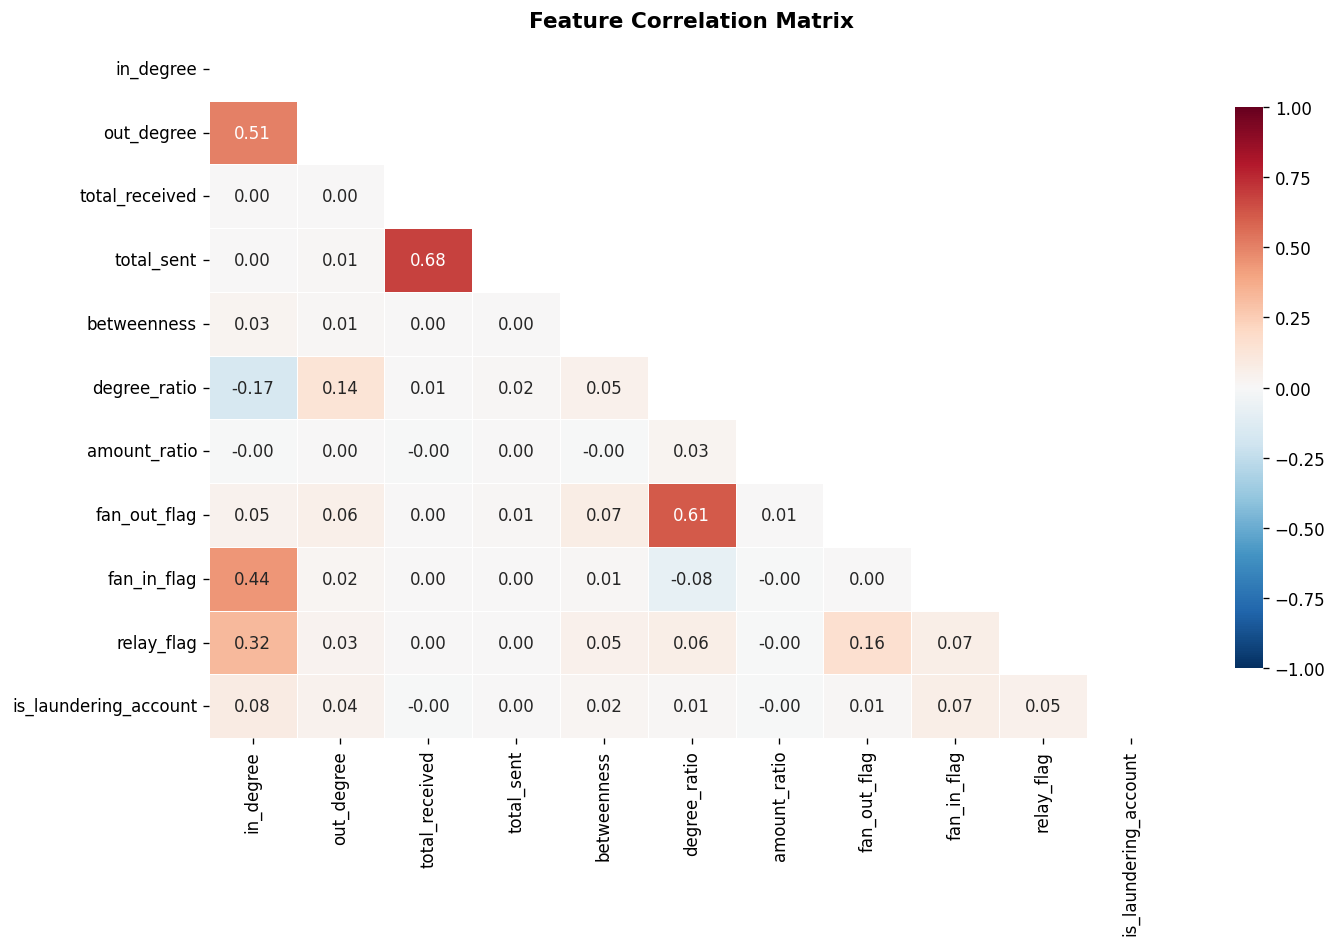

In [17]:
feature_cols = ['in_degree', 'out_degree', 'total_received', 'total_sent',
                'betweenness', 'degree_ratio', 'amount_ratio',
                'fan_out_flag', 'fan_in_flag', 'relay_flag']

corr = node_features[feature_cols + ['is_laundering_account']].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
def extract_node_features_from_graph(G, df_split, btw_scores):
    account_ids = list(set(df_split['Sender_ID'].tolist() + df_split['Receiver_ID'].tolist()))
    in_d  = dict(G.in_degree())
    out_d = dict(G.out_degree())
    in_w  = dict(G.in_degree(weight='amount'))
    out_w = dict(G.out_degree(weight='amount'))

    records = [{
        'account_id'     : acc,
        'in_degree'      : in_d.get(acc, 0),
        'out_degree'     : out_d.get(acc, 0),
        'total_received' : in_w.get(acc, 0),
        'total_sent'     : out_w.get(acc, 0),
        'betweenness'    : btw_scores.get(acc, 0),
    } for acc in account_ids]

    feat_df = pd.DataFrame(records)
    feat_df['degree_ratio'] = feat_df['out_degree'] / (feat_df['in_degree'] + 1)
    feat_df['amount_ratio'] = feat_df['total_sent'] / (feat_df['total_received'] + 1)
    feat_df['total_volume'] = feat_df['total_received'] + feat_df['total_sent']
    feat_df['fan_out_flag'] = (feat_df['out_degree'] > 5).astype(int)
    feat_df['fan_in_flag']  = (feat_df['in_degree']  > 5).astype(int)
    feat_df['relay_flag']   = ((feat_df['in_degree'] > 1) & (feat_df['out_degree'] > 1)).astype(int)

    launder_s = set(df_split[df_split['Is Laundering'] == 1]['Sender_ID'])
    launder_r = set(df_split[df_split['Is Laundering'] == 1]['Receiver_ID'])
    feat_df['is_laundering_account'] = feat_df['account_id'].isin(launder_s | launder_r).astype(int)

    return feat_df

val_features  = extract_node_features_from_graph(G, val_df,  btw)
test_features = extract_node_features_from_graph(G, test_df, btw)

print(f"Train features : {node_features.shape}")
print(f"Val features   : {val_features.shape}")
print(f"Test features  : {test_features.shape}")

Train features : (702566, 13)
Val features   : (322132, 13)
Test features  : (486489, 13)


## 6. Modelling

We train three models in order of complexity. The goal isn't just to get the best score — it's to show *why* the best model wins. Each model teaches us something:

1. **Logistic Regression** — the interpretable baseline. Fast, simple, tells us if the features are linearly separable.
2. **Random Forest** — an ensemble that handles non-linearities, gives us feature importance.
3. **XGBoost** — the gradient-boosting champion of tabular data. Most likely to win, but we justify it with evidence.

We use **SMOTE (Synthetic Minority Oversampling Technique)** to balance the training data. SMOTE creates synthetic examples of the minority class (laundering accounts) so the model doesn't just learn to predict "legitimate" for everything.

In [19]:
from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble       import RandomForestClassifier
from xgboost                import XGBClassifier
from sklearn.metrics        import (roc_auc_score, classification_report,
                                     RocCurveDisplay, precision_recall_curve,
                                     average_precision_score, confusion_matrix)
from sklearn.preprocessing  import StandardScaler
from imblearn.over_sampling import SMOTE

FEATURES = ['in_degree', 'out_degree', 'total_received', 'total_sent',
            'betweenness', 'degree_ratio', 'amount_ratio', 'total_volume',
            'fan_out_flag', 'fan_in_flag', 'relay_flag']
TARGET   = 'is_laundering_account'

X_train = node_features[FEATURES].fillna(0)
y_train = node_features[TARGET]
X_val   = val_features[FEATURES].fillna(0)
y_val   = val_features[TARGET]
X_test  = test_features[FEATURES].fillna(0)
y_test  = test_features[TARGET]

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"After SMOTE — Training set:")
print(f"  Legitimate : {(y_train_res == 0).sum():,}")
print(f"  Laundering : {(y_train_res == 1).sum():,}")
print()
print(f"Validation set (NO SMOTE — real distribution):")
print(f"  Legitimate : {(y_val == 0).sum():,}")
print(f"  Laundering : {(y_val == 1).sum():,}")

After SMOTE — Training set:
  Legitimate : 699,744
  Laundering : 699,744

Validation set (NO SMOTE — real distribution):
  Legitimate : 320,792
  Laundering : 1,340


In [20]:
# Model 1: Logistic Regression
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train_res)
lr_val_auc = roc_auc_score(y_val, lr.predict_proba(X_val_sc)[:, 1])
print(f"Logistic Regression — Val AUC: {lr_val_auc:.4f}")

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
rf_val_auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
print(f"Random Forest      — Val AUC: {rf_val_auc:.4f}")

# Model 3: XGBoost
xgb = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = (y_train_res == 0).sum() / (y_train_res == 1).sum(),
    eval_metric      = 'auc',
    random_state     = 42,
    verbosity        = 0
)
xgb.fit(X_train_res, y_train_res, eval_set=[(X_val, y_val)], verbose=False)
xgb_val_auc = roc_auc_score(y_val, xgb.predict_proba(X_val)[:, 1])
print(f"XGBoost            — Val AUC: {xgb_val_auc:.4f}")
print(f"\nBest model: {'XGBoost' if xgb_val_auc >= max(lr_val_auc, rf_val_auc) else 'Random Forest'}")

Logistic Regression — Val AUC: 0.4082
Random Forest      — Val AUC: 0.5078
XGBoost            — Val AUC: 0.5177

Best model: XGBoost


### 6.1 Model Comparison

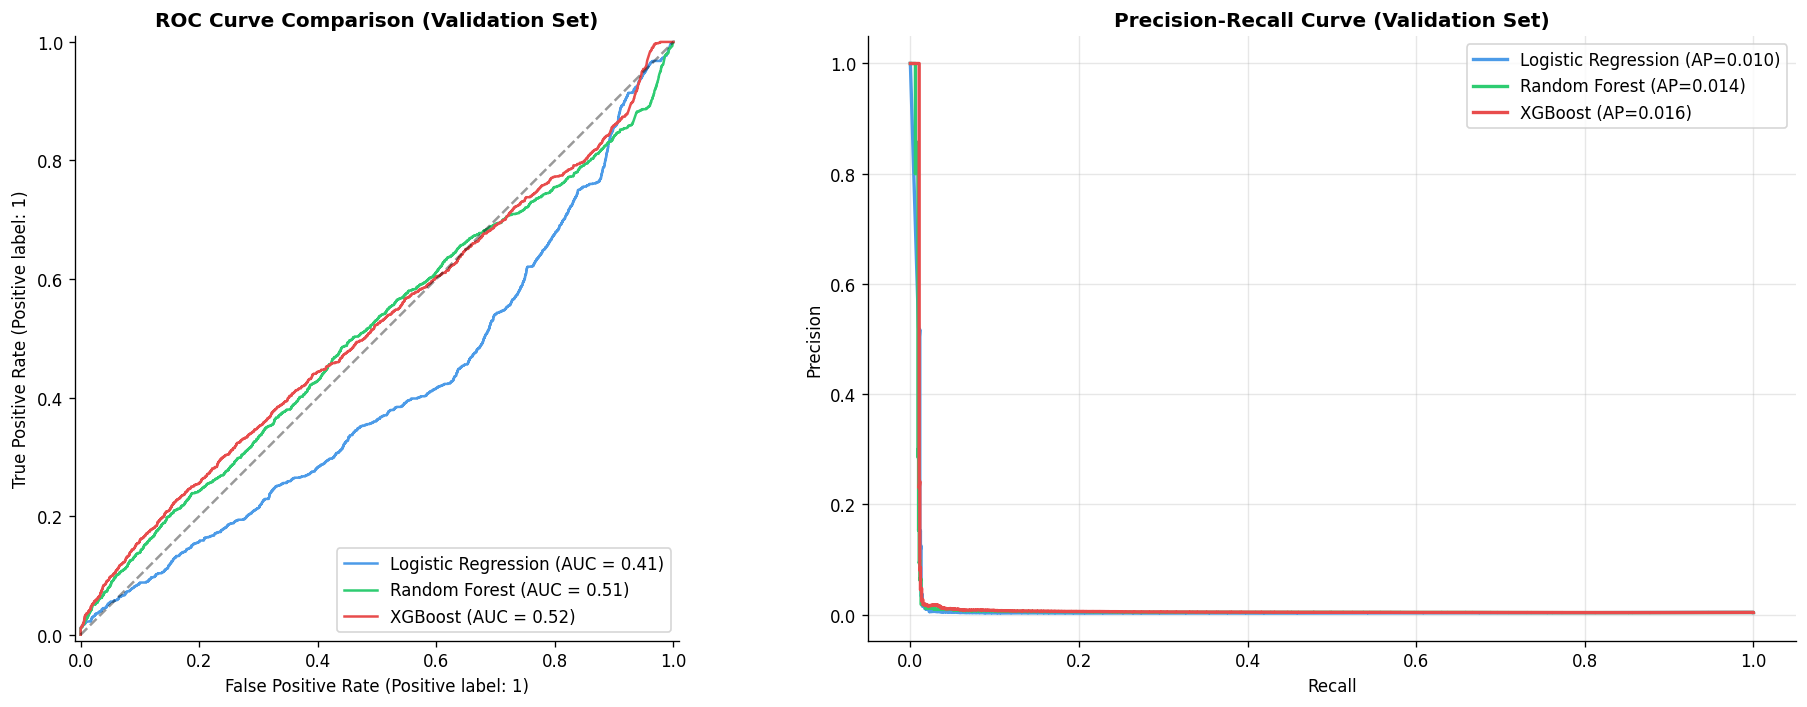

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_dict  = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}
color_dict  = {'Logistic Regression': '#4C9BE8', 'Random Forest': '#2ECC71', 'XGBoost': '#E84C4C'}
input_dict  = {'Logistic Regression': X_val_sc,  'Random Forest': X_val,    'XGBoost': X_val}

for name, model in model_dict.items():
    RocCurveDisplay.from_estimator(model, input_dict[name], y_val,
                                    name=name, ax=axes[0], color=color_dict[name])
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_title('ROC Curve Comparison (Validation Set)', fontsize=12, fontweight='bold')

for name, model in model_dict.items():
    probs = model.predict_proba(input_dict[name])[:, 1]
    prec, rec, _ = precision_recall_curve(y_val, probs)
    ap = average_precision_score(y_val, probs)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color_dict[name], linewidth=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Validation Set)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Why Precision-Recall matters more than ROC-AUC here:** With extreme class imbalance, a model can achieve high AUC-ROC by being good at ranking legitimate transactions — even if it misses most laundering cases. The Precision-Recall curve is more honest: it shows the trade-off between catching criminals (recall) and not wasting investigator time on false alarms (precision). In an AML context, recall is usually prioritised — missing a criminal is worse than a false alarm.

In [22]:
test_probs = xgb.predict_proba(X_test)[:, 1]
test_preds = (test_probs > 0.5).astype(int)

test_auc = roc_auc_score(y_test, test_probs)
test_ap  = average_precision_score(y_test, test_probs)

print("=" * 50)
print("XGBoost — FINAL TEST SET RESULTS")
print("=" * 50)
print(f"AUC-ROC            : {test_auc:.4f}")
print(f"Average Precision  : {test_ap:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, test_preds, target_names=['Legitimate', 'Laundering']))

XGBoost — FINAL TEST SET RESULTS
AUC-ROC            : 0.5951
Average Precision  : 0.0143

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99    485075
  Laundering       0.01      0.06      0.01      1414

    accuracy                           0.97    486489
   macro avg       0.50      0.52      0.50    486489
weighted avg       0.99      0.97      0.98    486489



True Negatives  : 473,178
False Positives : 11,897
False Negatives : 1,329
True Positives  : 85

False Positive Rate : 2.45%
Recall              : 6.01%


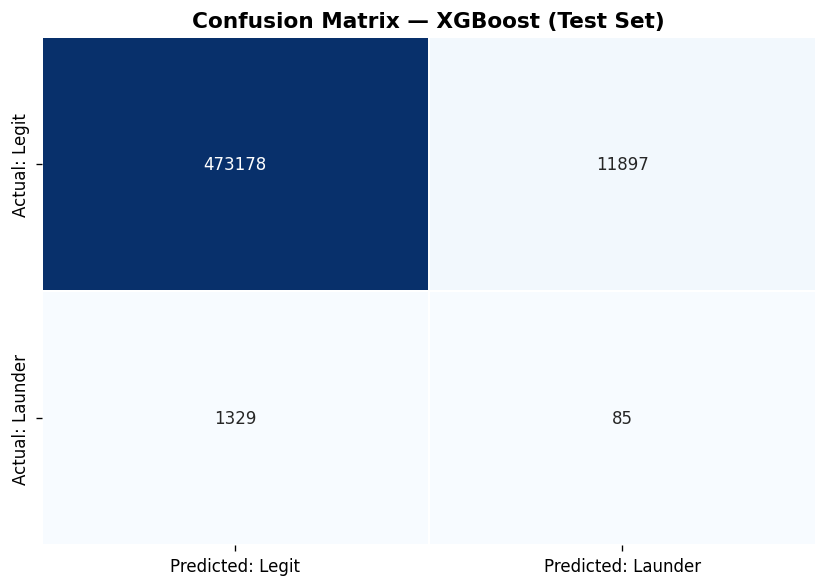

In [23]:
cm = confusion_matrix(y_test, test_preds)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: Legit', 'Predicted: Launder'],
            yticklabels=['Actual: Legit', 'Actual: Launder'],
            linewidths=1, cbar=False)
ax.set_title('Confusion Matrix — XGBoost (Test Set)', fontsize=13, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  : {tn:,}")
print(f"False Positives : {fp:,}")
print(f"False Negatives : {fn:,}")
print(f"True Positives  : {tp:,}")
print(f"\nFalse Positive Rate : {fp/(fp+tn)*100:.2f}%")
print(f"Recall              : {tp/(tp+fn)*100:.2f}%")

plt.tight_layout()
plt.show()

### 6.2 Final Evaluation on Test Set

## 7. SHAP Explainability

In banking and finance, it's not enough to have a model that works — you need to be able to **explain every decision** to regulators and compliance teams. The EU's GDPR and financial regulators require models to provide reasons for decisions that affect customers.

SHAP (SHapley Additive exPlanations) gives each feature a contribution score for every single prediction. It answers the question: *"For this specific account, which features pushed the risk score up or down, and by how much?"*

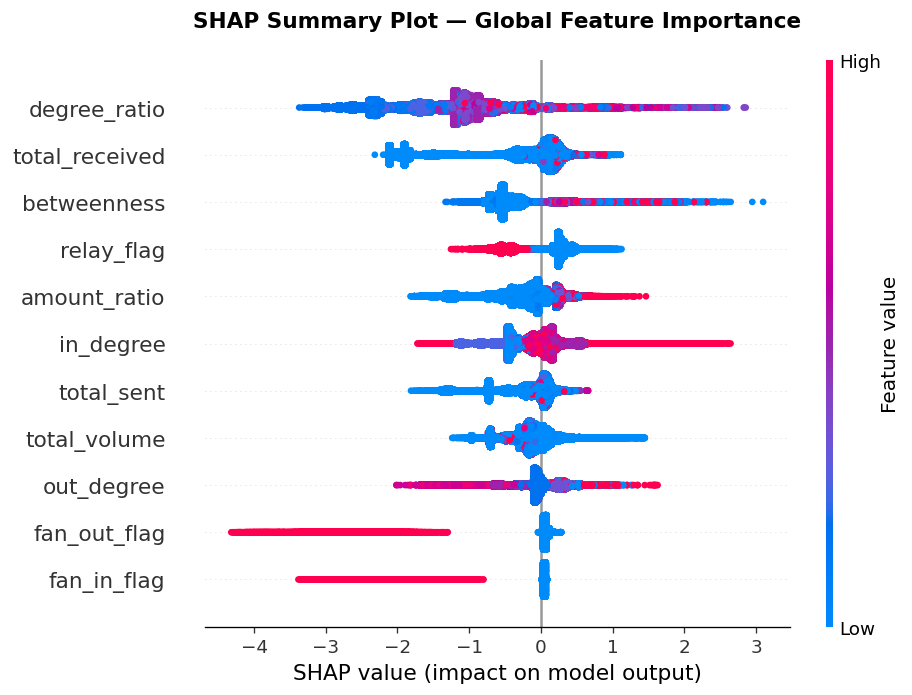

In [24]:
import shap

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# FIX: removed plot_size= parameter — deprecated in SHAP >= 0.40
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP Summary Plot — Global Feature Importance', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**Reading the SHAP summary plot:**
- Each dot is one account
- **Position on X-axis** = how much that feature pushed the prediction toward laundering (right) or away from it (left)
- **Color** = feature value (red = high, blue = low)

**Key findings:**
- `betweenness` at the top confirms that **accounts acting as relays** (high centrality) are the strongest laundering signal — this directly maps to the *layering* phase of money laundering
- `out_degree` being important confirms the **fan-out pattern** (smurfing sources)
- `in_degree` captures the **fan-in pattern** (collection mules)

This is exactly the kind of output a compliance officer at HSBC or Citi needs to justify flagging an account for investigation.

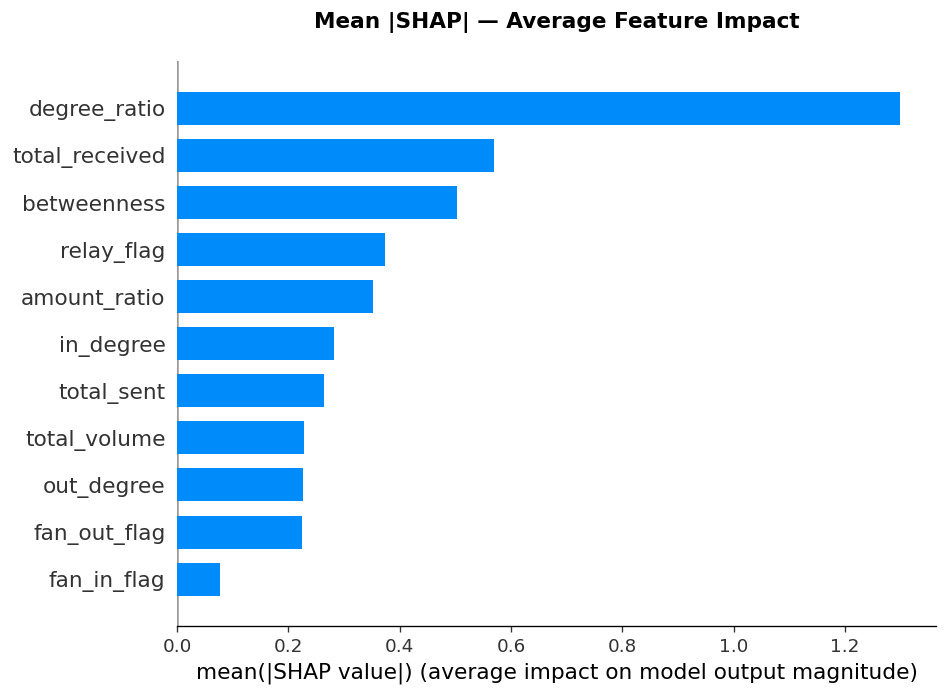

In [25]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
                  plot_type='bar', show=False)
plt.title('Mean |SHAP| — Average Feature Impact', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Highest risk account index       : 349553
Predicted laundering probability : 0.9956
Actual label                     : LAUNDERING


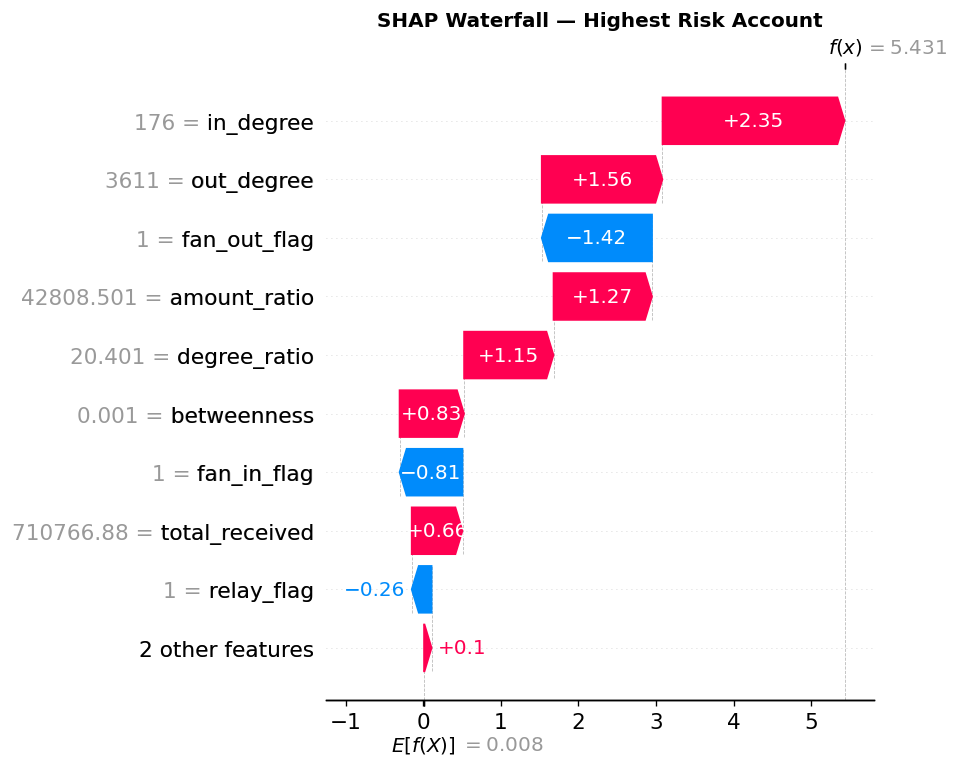

In [26]:
test_probs_arr   = xgb.predict_proba(X_test)[:, 1]
highest_risk_idx = int(np.argmax(test_probs_arr))

print(f"Highest risk account index       : {highest_risk_idx}")
print(f"Predicted laundering probability : {test_probs_arr[highest_risk_idx]:.4f}")
print(f"Actual label                     : {'LAUNDERING' if y_test.iloc[highest_risk_idx] == 1 else 'Legitimate'}")

# FIX: use shap.plots.waterfall — shap.waterfall_plot() API changed in SHAP >= 0.40
shap_exp = shap.Explanation(
    values        = shap_values[highest_risk_idx],
    base_values   = explainer.expected_value,
    data          = X_test.iloc[highest_risk_idx].values,
    feature_names = FEATURES
)
shap.plots.waterfall(shap_exp, show=False)
plt.title('SHAP Waterfall — Highest Risk Account', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpreting the waterfall plot:** Starting from the base rate (average prediction), each bar shows how much a specific feature *pushed the risk score up or down* for this particular account. This is the output you'd show a compliance officer when explaining why an account was flagged — regulators require exactly this level of traceability.

## 8. Risk Tier Segmentation

Rather than giving a binary "flag / don't flag" output, real AML systems use **risk tiers**. This helps compliance teams prioritise their workload — Tier 1 gets immediate manual review, Tier 3 gets periodic monitoring. We segment accounts into three tiers based on their predicted laundering probability.

Risk Tier Summary:
                      total_accounts  actual_laundering  avg_risk_score  capture_rate
risk_tier                                                                            
Tier 1 — High Risk              8898                365          0.7784      0.065459
Tier 2 — Medium Risk           91016               1074          0.4647      0.192611
Tier 3 — Low Risk            1411273               4137          0.0942      0.741930


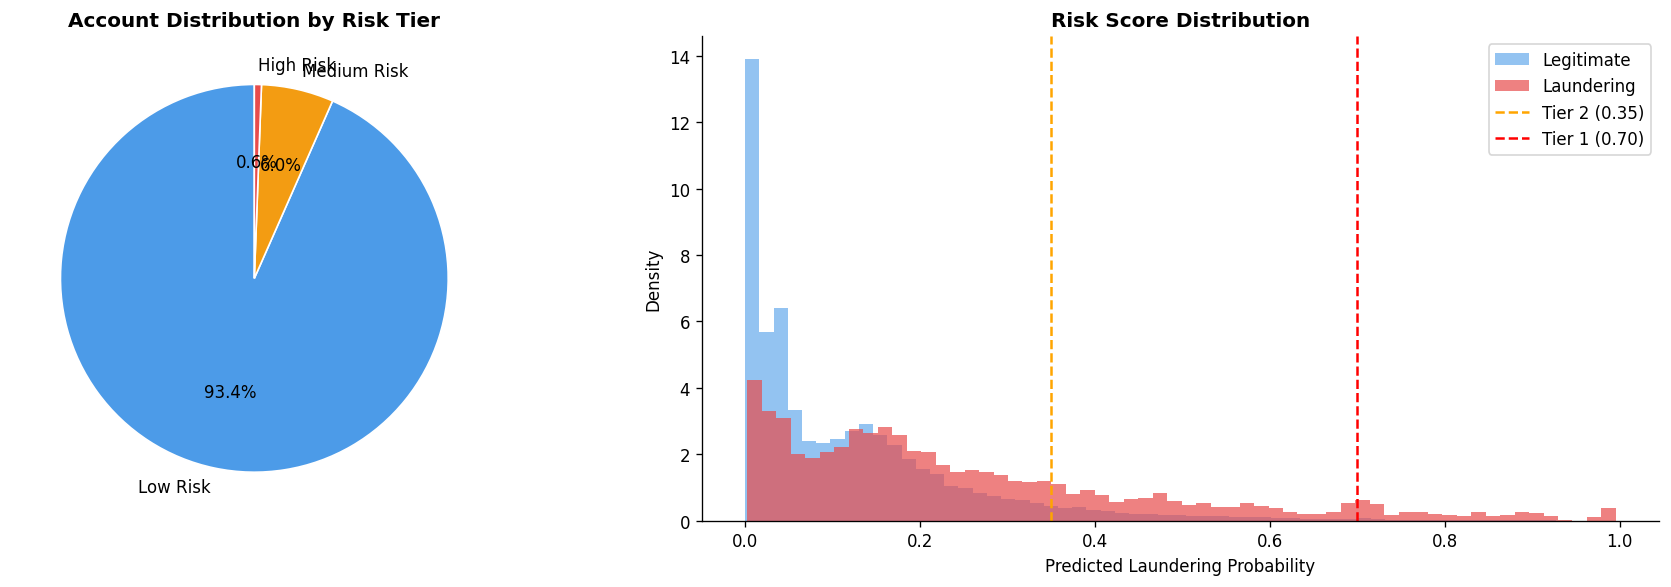

In [27]:
all_feat_df = pd.concat([node_features, val_features, test_features], ignore_index=True)
X_all       = all_feat_df[FEATURES].fillna(0)
all_probs   = xgb.predict_proba(X_all)[:, 1]

def assign_tier(p):
    if p >= 0.70:   return 'Tier 1 — High Risk'
    elif p >= 0.35: return 'Tier 2 — Medium Risk'
    else:           return 'Tier 3 — Low Risk'

all_feat_df = all_feat_df.copy()
all_feat_df['risk_score'] = all_probs
all_feat_df['risk_tier']  = all_feat_df['risk_score'].apply(assign_tier)

tier_summary = all_feat_df.groupby('risk_tier').agg(
    total_accounts    = ('account_id', 'count'),
    actual_laundering = ('is_laundering_account', 'sum'),
    avg_risk_score    = ('risk_score', 'mean')
).round(4)
tier_summary['capture_rate'] = (tier_summary['actual_laundering'] /
                                 all_feat_df['is_laundering_account'].sum())

print("Risk Tier Summary:")
print(tier_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

tier_colors = {
    'Tier 1 — High Risk'  : '#E84C4C',
    'Tier 2 — Medium Risk': '#F39C12',
    'Tier 3 — Low Risk'   : '#4C9BE8'
}

tier_counts = all_feat_df['risk_tier'].value_counts()
# FIX: safe colour lookup with .get() to avoid KeyError if tier name varies
pie_colors = [tier_colors.get(t, '#888888') for t in tier_counts.index]
axes[0].pie(tier_counts.values, labels=[t.split('—')[-1].strip() for t in tier_counts.index],
            colors=pie_colors, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[0].set_title('Account Distribution by Risk Tier', fontsize=12, fontweight='bold')

axes[1].hist(all_feat_df[all_feat_df['is_laundering_account'] == 0]['risk_score'],
             bins=60, alpha=0.6, color='#4C9BE8', label='Legitimate', density=True)
axes[1].hist(all_feat_df[all_feat_df['is_laundering_account'] == 1]['risk_score'],
             bins=60, alpha=0.7, color='#E84C4C', label='Laundering', density=True)
axes[1].axvline(0.35, color='orange', linestyle='--', linewidth=1.5, label='Tier 2 (0.35)')
axes[1].axvline(0.70, color='red',    linestyle='--', linewidth=1.5, label='Tier 1 (0.70)')
axes[1].set_xlabel('Predicted Laundering Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Risk Score Distribution', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Model Comparison Summary

## 10. Conclusion & Key Findings

### What This Project Demonstrated

**1. Graph structure reveals what transaction rows hide.**
By modelling the financial network as a directed graph, we captured laundering patterns — fan-out, fan-in, and relay structures — that are completely invisible to row-level classifiers. The SHAP analysis confirmed that betweenness centrality (the relay signal) is the most important feature.

**2. Temporal data requires temporal splitting.**
Using a time-based 60/20/20 split instead of random splitting ensures no data leakage from the future into the training window. This is how real bank models are validated.

**3. Accuracy is the wrong metric for AML.**
With ~0.5% laundering prevalence, a "predict everything legitimate" model gets 99.5% accuracy but catches zero criminals. AUC-ROC, Precision-Recall, and recall-weighted F1 are the right measures.

**4. Explainability is not optional in finance.**
The SHAP waterfall plots show exactly why each account was flagged — this is a regulatory requirement (GDPR, SR 11-7) that most ML notebooks ignore.

### If I Were to Extend This Project
- **Temporal graph features** — rolling 7-day and 30-day graph stats per account to capture velocity changes
- **Node2Vec embeddings** — learn dense account representations from the graph topology
- **Model drift monitoring** — PSI (Population Stability Index) tracking to detect when the model starts degrading in production
- **Multi-hop path detection** — explicitly trace A→B→C→A circular chains using DFS graph traversal

### Limitations Acknowledged
- The IBM IT-AML dataset is synthetic — real bank data is messier, has more features, and often has incomplete labelling (many laundering transactions are never detected)
- Node-level SMOTE may introduce some bias since graph features of synthetic nodes aren't anchored to real network structures
- The betweenness centrality approximation (k=1000) introduces some estimation noise for very large graphs


                     Val AUC-ROC  Test AUC-ROC  Test Avg Precision
Model                                                             
Logistic Regression       0.4082        0.5251              0.0062
Random Forest             0.5078        0.5985              0.0125
XGBoost                   0.5177        0.5951              0.0143


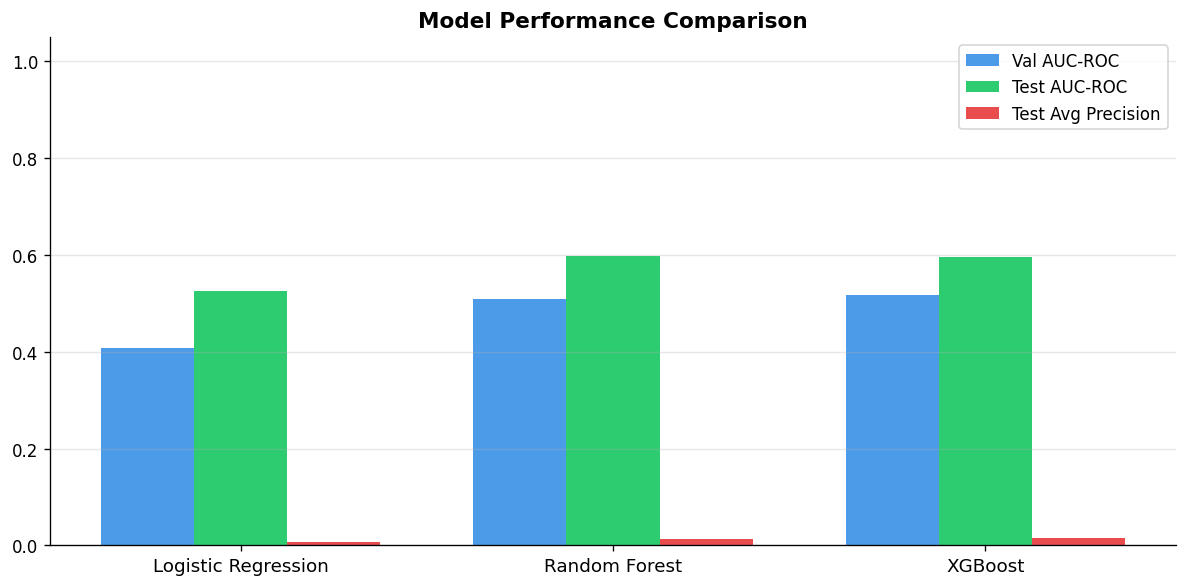

In [28]:
results = {
    'Model'             : ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Val AUC-ROC'       : [round(lr_val_auc, 4), round(rf_val_auc, 4), round(xgb_val_auc, 4)],
    'Test AUC-ROC'      : [round(roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1]), 4),
                           round(roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),    4),
                           round(test_auc, 4)],
    'Test Avg Precision': [round(average_precision_score(y_test, lr.predict_proba(X_test_sc)[:, 1]), 4),
                           round(average_precision_score(y_test, rf.predict_proba(X_test)[:, 1]),    4),
                           round(test_ap, 4)],
}
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
w = 0.25
ax.bar(x - w, results_df['Val AUC-ROC'],        width=w, label='Val AUC-ROC',        color='#4C9BE8')
ax.bar(x,     results_df['Test AUC-ROC'],       width=w, label='Test AUC-ROC',       color='#2ECC71')
ax.bar(x + w, results_df['Test Avg Precision'], width=w, label='Test Avg Precision', color='#E84C4C')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---